<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

#завдання 0

In [1]:
!pip install opendatasets --upgrade --quiet
!pip install pyarrow --quiet
!pip -q install gdown

In [2]:
import opendatasets as od
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_curve, auc, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
import gdown
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'

In [6]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nadiiababanska
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 756MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-4/bank-customer-churn-prediction-dlu-course-c-4.zip to ./bank-customer-churn-prediction-dlu-course-c-4


In [7]:
test_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [8]:
sample_submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')

#завдання 1

Area under ROC score on Training dataset: 0.83%
F1 score: 0.66%


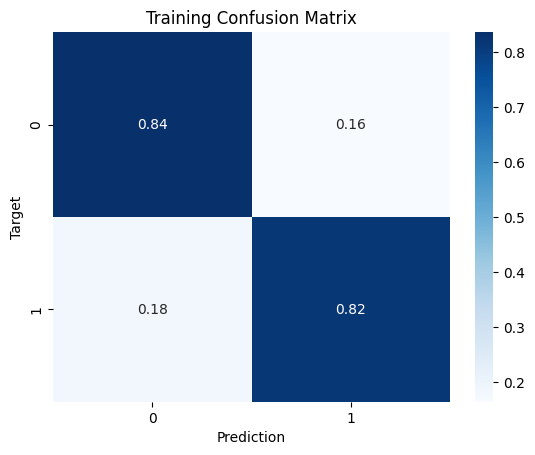

Area under ROC score on Validation dataset: 0.81%
F1 score: 0.64%


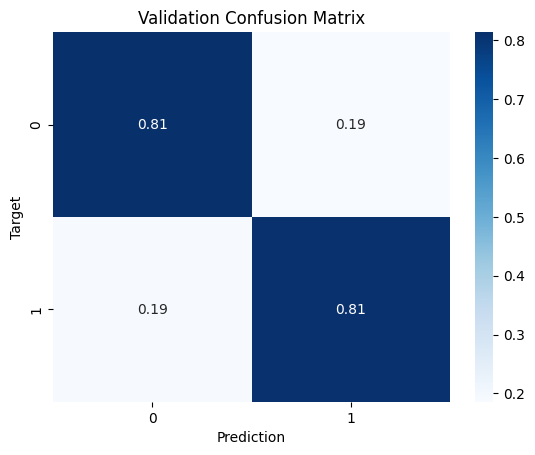

['model_pipeline_lin_reg.joblib']

In [9]:
raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42,
                                     stratify = raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(raw_df.drop(['Exited'], axis=1).columns)
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_lin_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced', C=0.1))
])

# Тренуємо пайплайн
model_pipeline_lin_reg.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline_lin_reg, inputs, targets, name=''):
    preds = model_pipeline_lin_reg.predict(inputs)
    fpr, tpr, thresholds = roc_curve(targets, preds, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    f1 = f1_score(targets, preds, pos_label= 1)
    print("F1 score: {:.2f}%".format(f1))
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_lin_reg, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_lin_reg, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_lin_reg, 'model_pipeline_lin_reg.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Training dataset: 0.87%
F1 score: 0.73%


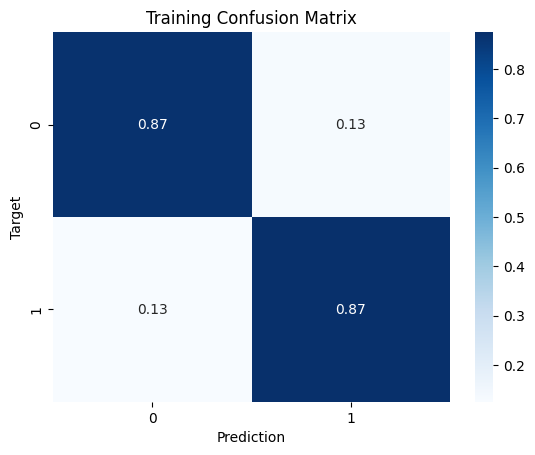

Area under ROC score on Validation dataset: 0.86%
F1 score: 0.70%


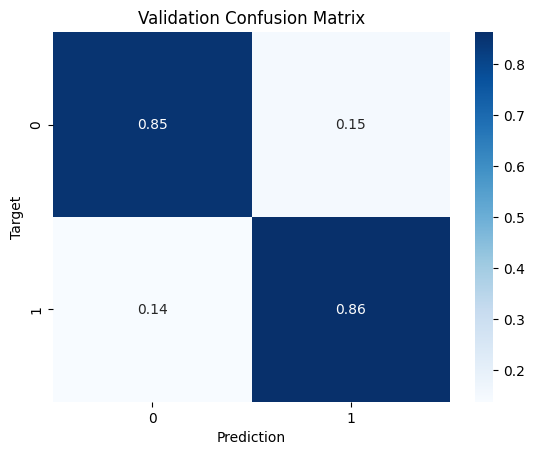

['model_pipeline_poly_2.joblib']

In [10]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('poly_features', PolynomialFeatures(degree = 2)),
    ('scaler', StandardScaler())

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly_2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced', C=0.5))
])

# Тренуємо пайплайн
model_pipeline_poly_2.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline_poly_2, inputs, targets, name=''):
    preds = model_pipeline_poly_2.predict(inputs)
    fpr, tpr, thresholds = roc_curve(targets, preds, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    f1 = f1_score(targets, preds, pos_label= 1)
    print("F1 score: {:.2f}%".format(f1))
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_2, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_poly_2, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly_2, 'model_pipeline_poly_2.joblib')

#Висновок
Точність моделі трохи покращилась. Модель не має overfit чи underfit, тому що результати auroc на тренувальних та валідаційних даних доволі близькі, тобто модель добре генералізує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Training dataset: 0.87%
F1 score: 0.74%


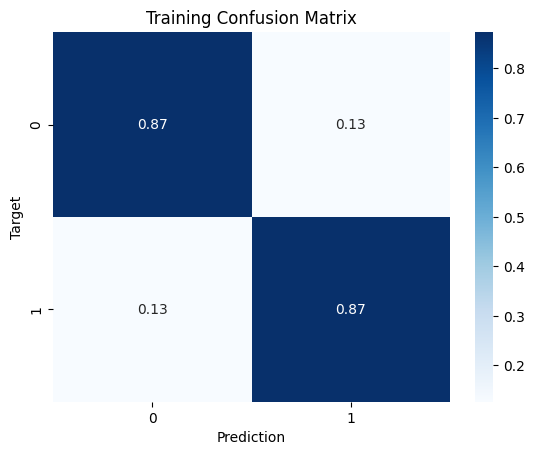

Area under ROC score on Validation dataset: 0.85%
F1 score: 0.70%


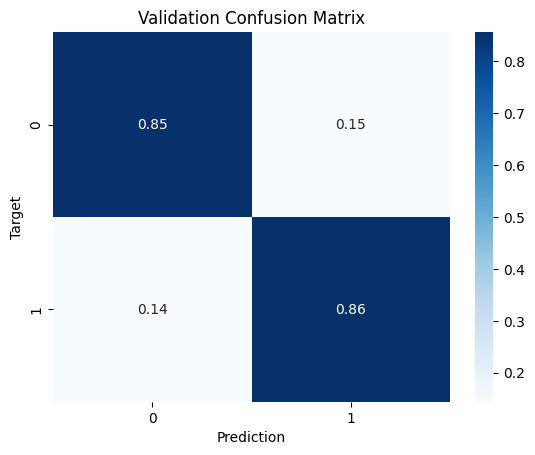

['log_reg.joblib']

In [11]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('poly_features', PolynomialFeatures(degree = 4)),
    ('scaler', StandardScaler())

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly_4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced', C=0.3))
])

# Тренуємо пайплайн
model_pipeline_poly_4.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline_poly_4, inputs, targets, name=''):
    preds = model_pipeline_poly_4.predict(inputs)
    fpr, tpr, thresholds = roc_curve(targets, preds, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    f1 = f1_score(targets, preds, pos_label= 1)
    print("F1 score: {:.2f}%".format(f1))
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_4, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline_poly_4, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly_4, 'log_reg.joblib')

#Висновок
Із додаванням поліноміальних ознак 2го степеню точність моделі покращилась. Проте зі збільшенням ступеню до 4го, точність моделі практично не змінилась, а ось розрив у точності на тренувальних даних та валідаційних - збільшився, що говорить про те, що модель стала гірше генералізувати. На мою думку в даному випадку доцільно лишити поліном 2го ступеню, але змінити ступінь генералізациї на 0.5.
Для полінома 4го ступеню, С практично не впливає на результуючу точніть моделі.

In [12]:
def calculate_data_for_submission(test_df):

 test_pred = model_pipeline_poly_4.predict_proba(test_df)[:, 1]
 test_df['Exited'] = test_pred
 sample_submission_df['Exited'] = sample_submission_df['id'].map(
      test_df.set_index('id')['Exited']
)

 sample_submission_df.to_csv('submission_log_reg.csv', index=False)
 return


In [13]:
calculate_data_for_submission(test_df)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [14]:
url_application_data_csv_zip = "https://drive.google.com/file/d/1xUtKnMxLCLhSsnbjyKN8tXbjgqPTRPdI/view?usp=share_link"

gdown.download(url_application_data_csv_zip, "regression_data.csv", fuzzy=True)

regression_data_df = pd.read_csv('regression_data.csv')


Downloading...
From: https://drive.google.com/uc?id=1xUtKnMxLCLhSsnbjyKN8tXbjgqPTRPdI
To: /content/regression_data.csv
100%|██████████| 15.1k/15.1k [00:00<00:00, 19.8MB/s]


In [15]:
regression_data_df.head(5)

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [16]:

train_data, val_data = train_test_split(regression_data_df, test_size=0.2, random_state=42)


In [17]:
# Створюємо трен. і вал. набори
inp_cols = list(regression_data_df.drop(['target'], axis=1).columns)
tar_col = 'target'


In [18]:
inp_cols, tar_col

(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'], 'target')

In [19]:
train_data_inputs, train_data_targets = train_data[inp_cols].copy(), train_data[tar_col].copy()
val_data_inputs, val_data_targets = val_data[inp_cols].copy(), val_data[tar_col].copy()

# Виявляємо числові і категоріальні колонки
num_cols = train_data_inputs.select_dtypes(include=np.number).columns.tolist()

In [20]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('poly_features', PolynomialFeatures(degree = 5)),
    ('scaler', StandardScaler())

])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, num_cols)])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly_5 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

# Тренуємо пайплайн
model_pipeline_poly_5.fit(train_data_inputs, train_data_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)

    return preds, rmse, r2

# Оцінюємо модель на трен і вал даних

train_predictions, rmse_lin_train, r2_train = predict_and_plot(model_pipeline_poly_5, train_data_inputs, train_data_targets, 'Training')
val_predictions, rmse_lin_val, r2_validation = predict_and_plot(model_pipeline_poly_5, val_data_inputs, val_data_targets, 'Validation')

print(f"Train RMSE: {rmse_lin_train:.3f}")
print(f"Train R^2: {r2_train:.3f}")

print(f"mean_test: {(np.mean(train_data_targets)):.2f}")
print(f"std_test: {(np.std(train_data_targets)):.2f}")
print(f"min_test: {(np.min(train_data_targets)):.2f}\n")



print(f"Validation RMSE: {rmse_lin_val:.3f}")
print(f"Validation R^2: {r2_validation:.3f}")

print(f"mean_test: {(np.mean(val_data_targets)):.2f}")
print(f"std_test: {(np.std(val_data_targets)):.2f}")
print(f"min_test: {(np.min(val_data_targets)):.2f}")



# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly_5, 'poly5.joblib')

Train RMSE: 0.000
Train R^2: 1.000
mean_test: -6.45
std_test: 44.13
min_test: -111.75

Validation RMSE: 12.677
Validation R^2: 0.931
mean_test: 6.19
std_test: 48.30
min_test: -84.23


['poly5.joblib']

#Висновок
Судячи з ідеальних rmse та r^2 на train даних - модель ідеально вивчила всі тренувальні дані, тому на валідаційному наборі з"являється відчутна помилка(якщо порівнювати з std). Висновок, ця модель не є хорошою, бо вона перенавчена і погано генералізує.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [40]:
def pipeline_build_and_train(model, degree, train_inputs, train_targets, val_inputs, val_targets):
  numeric_transformer = Pipeline(steps=[
    ('poly_features', PolynomialFeatures(degree = degree)),
    ('scaler', StandardScaler())
    ])

  preprocessor = ColumnTransformer(
    transformers=[
        ('num',numeric_transformer, num_cols)
    ])

  model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
    ])

  model_pipeline.fit(train_inputs, train_targets)

  train_preds = model_pipeline.predict(train_inputs)
  val_preds = model_pipeline.predict(val_inputs)

  train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
  train_r2 = r2_score(train_targets, train_preds)
  val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
  val_r2 = r2_score(val_targets, val_preds)

  return model_pipeline, train_rmse, train_r2, val_rmse, val_r2

In [53]:
models = [
    LinearRegression(),
    Ridge(alpha=0.5),
    Lasso(alpha=0.5),
    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
]

In [52]:
for model in models:
  model_pipeline, train_rmse, train_r2, val_rmse, val_r2 = pipeline_build_and_train(model, 20, train_data_inputs, train_data_targets, val_data_inputs, val_data_targets)
  print(f"{type(model).__name__}: Train RMSE={train_rmse:.3f}, Val RMSE={val_rmse:.3f}\n")

print(f"mean_test: {(np.mean(train_data_targets)):.2f}")
print(f"std_test: {(np.std(train_data_targets)):.2f}")
print(f"min_test: {(np.min(train_data_targets)):.2f}\n")

print(f"mean_test: {(np.mean(val_data_targets)):.2f}")
print(f"std_test: {(np.std(val_data_targets)):.2f}")
print(f"min_test: {(np.min(val_data_targets)):.2f}")


LinearRegression: Train RMSE=0.000, Val RMSE=65.391

Ridge: Train RMSE=0.660, Val RMSE=41.760

Lasso: Train RMSE=1.199, Val RMSE=1.006

ElasticNet: Train RMSE=8.603, Val RMSE=17.330

mean_test: -6.45
std_test: 44.13
min_test: -111.75

mean_test: 6.19
std_test: 48.30
min_test: -84.23


#Висновок
Лініна регресія при такій кількості ознак просто завчила всі дані і на валідаційній вибірці показала найгірше передбачення. rmse 65 - це гірше ніж просто передбачати середнє(48)

Для решти моделей я застосувала спочтаку альфа = 0.1 і вони теж показали себе не дуже. Проте з альфа = 0.5, моделі далі показали кращу точність, крім ElasticNet.

В цілому найкращою  показала себе Lasso, вона відкинула всі незначущі ознаки і показала близький результат на тренувальних та валідаційних даних, що означає, що модель добре генералізує.

In [57]:
lasso_pipeline, _, _, _, _ =  pipeline_build_and_train(
    Lasso(alpha=0.5, max_iter=10000), 20,
    train_data_inputs, train_data_targets,
    val_data_inputs, val_data_targets
)

#Після цього запускай аналіз ознак. Спробуй.
# отримуємо назви ознак після трансформації
feature_names = lasso_pipeline.named_steps['preprocessor']\
    .get_feature_names_out()

# отримуємо коефіцієнти Lasso
lasso_coefs = lasso_pipeline.named_steps['classifier'].coef_

# збираємо в датафрейм і фільтруємо ненульові
coef_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coefs})
nonzero_df = coef_df[coef_df['coef'] != 0].sort_values('coef', ascending=False)

print(f"Всього ознак: {len(feature_names)}")
print(f"Ненульових коефіцієнтів: {len(nonzero_df)}")
print(nonzero_df)

Всього ознак: 53130
Ненульових коефіцієнтів: 1
          feature       coef
4  num__feature_4  43.620753
